# IMPORT

In [42]:
import os
import re
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# FUNCTION

In [43]:
def clean_text(
        text,
        methods=['rmv_link', 'rmv_punc', 'lower', 'rmv_space'],
        custom_punctuation = '!"#$%&\'()*+,.-:;<=>?@[\\]^_/`{|}~”“',
    ):
    cleaned_text = text
    for method in methods:
        if method == 'rmv_link':
            # Remove link
            cleaned_text = re.sub('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', cleaned_text)
            cleaned_text = "".join(cleaned_text)
        elif method == 'rmv_punc':
            # Remove punctuation
            cleaned_text = re.sub('[%s]' % re.escape(custom_punctuation), '' , cleaned_text)
        elif method == 'lower':
            # Lowercase
            cleaned_text = cleaned_text.lower()
        elif method == 'rmv_space':
            # Remove extra space
            cleaned_text = re.sub(' +', ' ', cleaned_text)
            cleaned_text = cleaned_text.strip()
    return cleaned_text

<>:10: SyntaxWarning: invalid escape sequence '\('
<>:10: SyntaxWarning: invalid escape sequence '\('
C:\Users\ASUS\AppData\Local\Temp\ipykernel_16808\542473805.py:10: SyntaxWarning: invalid escape sequence '\('
  cleaned_text = re.sub('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', cleaned_text)


In [44]:
def preprocessing_text(text):
    text = text.replace("Vietstock - ", "")
    text = text.replace("\n", " ")
    text = clean_text(
        text=text,
        custom_punctuation="#$}{!)("
    )
    return text

# LOAD DATA

In [2]:
merge_data_path = r"F:\UNIVERSITY\Project\Sentiment-Analysis-Airflow\Financial-Sentiment-Analysis\projects_financial_connect_with_sentiment\save\merge_df.csv"
merge_df = pd.read_csv(merge_data_path)
merge_df["time"] = pd.to_datetime(merge_df["time"])

In [46]:
content_path = r"F:\UNIVERSITY\Project\Sentiment-Analysis-Airflow\Financial-Sentiment-Analysis\projects\data\sentiment_finance_news_with_scores.csv"
content_df = pd.read_csv(content_path)
content = content_df["main_content"]

In [56]:
len(content_df)

9982

# SPLIT BY YEAR AND MONTH

In [4]:
merge_df["year"] = merge_df["time"].dt.year
merge_df["month"] = merge_df["time"].dt.month

In [5]:
def get_df_by_year(df, year):
    return df[df["year"]==year]

def get_df_by_month(df, month):
    return df[df["month"]==month]

In [6]:
df_2021 = get_df_by_year(merge_df, 2021)
df_2022 = get_df_by_year(merge_df, 2022)
df_2023 = get_df_by_year(merge_df, 2023)
df_2024 = get_df_by_year(merge_df, 2024)
df_2025 = get_df_by_year(merge_df, 2025)
df_2026 = get_df_by_year(merge_df, 2026)

# EDA TEXT

=== TEXT STATISTICS ===
Total number of articles: 9982

Sample content lengths:
Average length: 3794.32 characters
Min length: 504 characters
Max length: 29911 characters


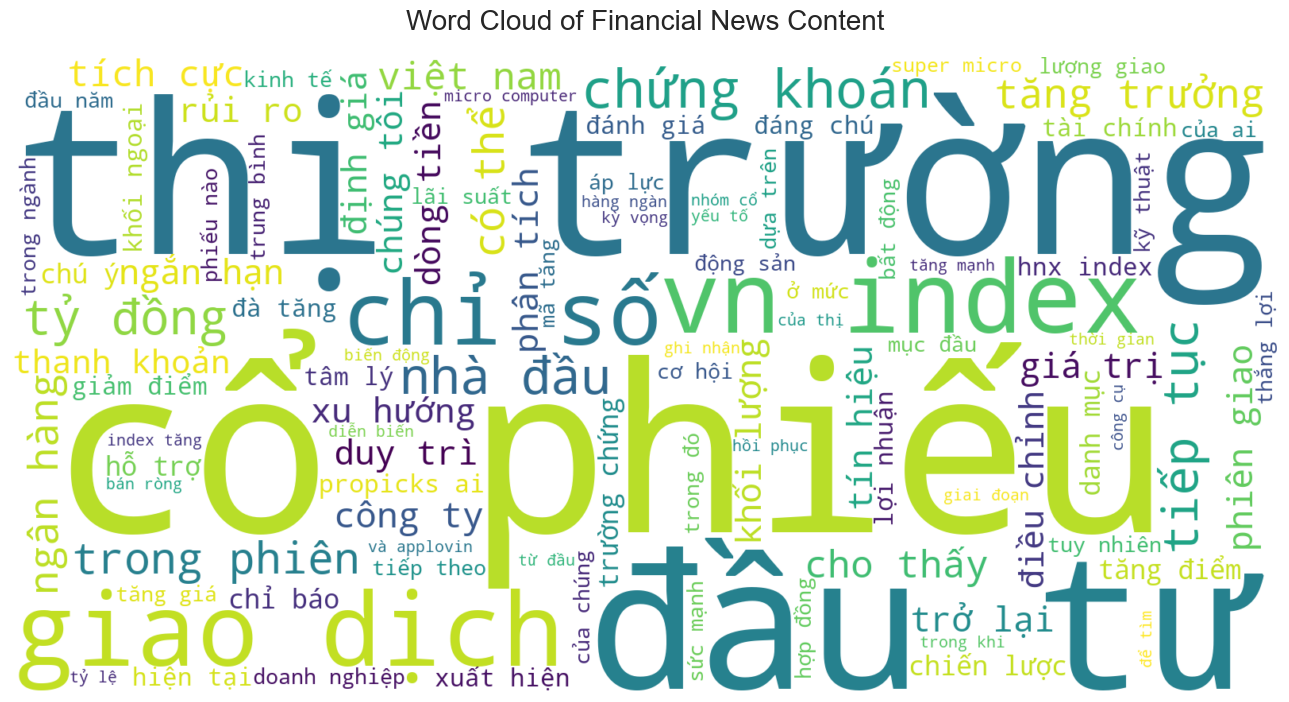


=== TOP 20 MOST COMMON WORDS ===
trong: 125655
tăng: 108161
và: 98776
của: 86680
với: 83063
cổ: 77535
phiếu: 69881
đầu: 69447
có: 64260
giá: 62876
thị: 62362
các: 59630
chỉ: 57532
phiên: 56204
giảm: 54540
trường: 52973
là: 49184
cho: 46273
điểm: 46171
đang: 45807


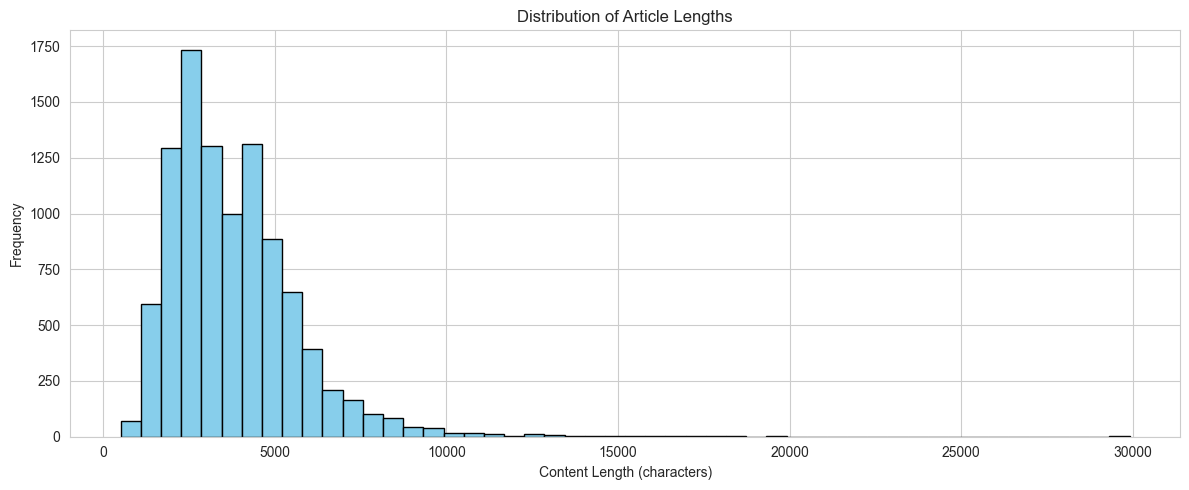

In [53]:
from wordcloud import WordCloud
from collections import Counter

# Basic text statistics
print("=== TEXT STATISTICS ===")
print(f"Total number of articles: {len(content)}")
print(f"\nSample content lengths:")
content_lengths = content.apply(len)
print(f"Average length: {content_lengths.mean():.2f} characters")
print(f"Min length: {content_lengths.min()} characters")
print(f"Max length: {content_lengths.max()} characters")

# Process all content for word cloud
all_text = ' '.join(content.values)

# Create word cloud
plt.figure(figsize=(13, 8))
wordcloud = WordCloud(
    width=1600, 
    height=800,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(all_text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Financial News Content', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

# Most common words
print("\n=== TOP 20 MOST COMMON WORDS ===")
words = all_text.split()
word_freq = Counter(words)
for word, count in word_freq.most_common(20):
    print(f"{word}: {count}")

# Distribution of content length
plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
plt.hist(content_lengths, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Content Length (characters)')
plt.ylabel('Frequency')
plt.title('Distribution of Article Lengths')

# plt.subplot(1, 2, 2)
# plt.boxplot(content_lengths, vert=True)
# plt.ylabel('Content Length (characters)')
# plt.title('Box Plot of Article Lengths')

plt.tight_layout()
plt.show()

In [71]:
# Create yearly statistics for content length
content_df['content_length'] = content_df['main_content'].apply(len)
yearly_stats = content_df.groupby('year')['content_length'].agg(['mean', 'median', 'count'])

# Create sentiment counts
sentiment_counts = content_df['sentiment_label'].value_counts()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16808\2398940494.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=content_df, x='sentiment_label', y='content_length', ax=ax3,


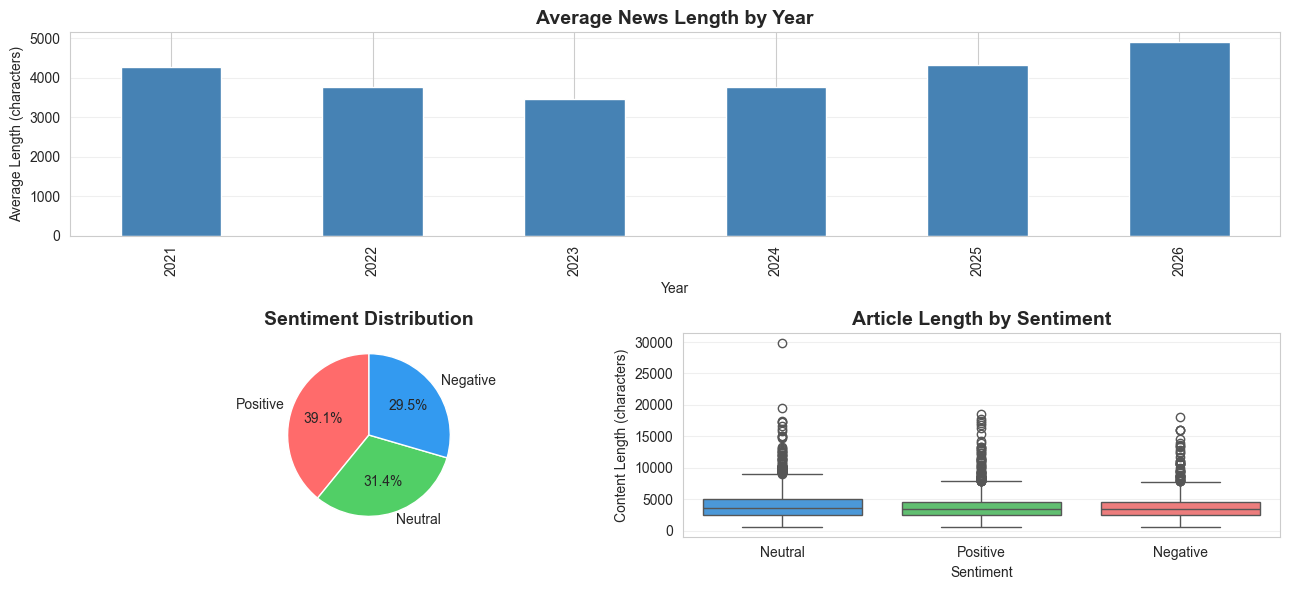

In [75]:
# Visualizations
fig = plt.figure(figsize=(13, 6))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# Plot 1: Average article length by year - spanning entire first row
ax1 = fig.add_subplot(gs[0, :])
yearly_stats['mean'].plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Average News Length by Year', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Length (characters)')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Sentiment distribution pie chart - bottom left
ax2 = fig.add_subplot(gs[1, 0])
sentiment_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90, 
                      colors=['#ff6b6b', '#51cf66', '#339af0'])
ax2.set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

# Plot 3: Content length vs sentiment - bottom right
ax3 = fig.add_subplot(gs[1, 1])
sns.boxplot(data=content_df, x='sentiment_label', y='content_length', ax=ax3, 
            palette={'Negative': '#ff6b6b', 'Positive': '#51cf66', 'Neutral': '#339af0'})
ax3.set_title('Article Length by Sentiment', fontsize=14, fontweight='bold')
ax3.set_xlabel('Sentiment')
ax3.set_ylabel('Content Length (characters)')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


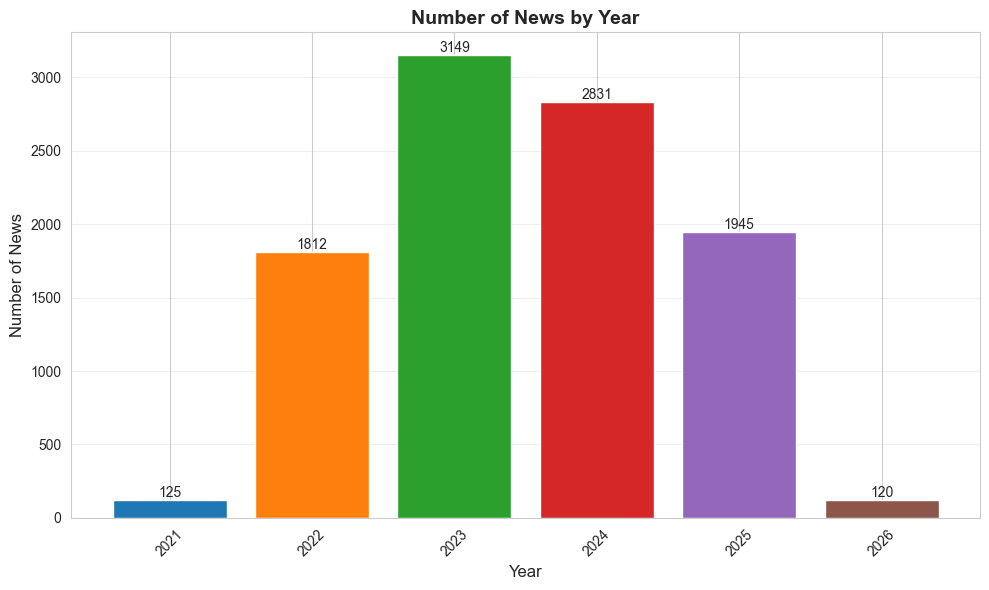

In [65]:
# Create color map for each year
colors_by_year = {
    2021: '#1f77b4',  # Blue
    2022: '#ff7f0e',  # Orange
    2023: '#2ca02c',  # Green
    2024: '#d62728',  # Red
    2025: '#9467bd',  # Purple
    2026: '#8c564b'   # Brown
}

# Get counts by year
year_counts = content_df.groupby("year")["main_content"].count()

# Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(year_counts.index, year_counts.values, 
               color=[colors_by_year[year] for year in year_counts.index])

plt.title('Number of News by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of News', fontsize=12)
plt.xticks(year_counts.index, rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# EDA PRICE

=== PRICE DATA STATISTICS ===
Time period: 2021-12-01 00:00:00 to 2026-01-22 00:00:00
Total trading days: 1034

Price statistics:
              open         high          low        close        volume
count  1034.000000  1034.000000  1034.000000  1034.000000  1.034000e+03
mean   1283.703385  1291.407544  1273.245880  1282.797959  7.255583e+08
std     197.529786   198.699001   195.410464   197.338859  3.056926e+08
min     876.000000   929.060000   873.780000   911.900000  2.151666e+08
25%    1145.937500  1155.172500  1137.232500  1143.810000  5.134105e+08
50%    1253.130000  1259.045000  1244.965000  1252.640000  6.659409e+08
75%    1343.497500  1349.645000  1331.665000  1341.867500  8.525765e+08
max    1910.320000  1918.460000  1884.600000  1902.930000  2.698902e+09


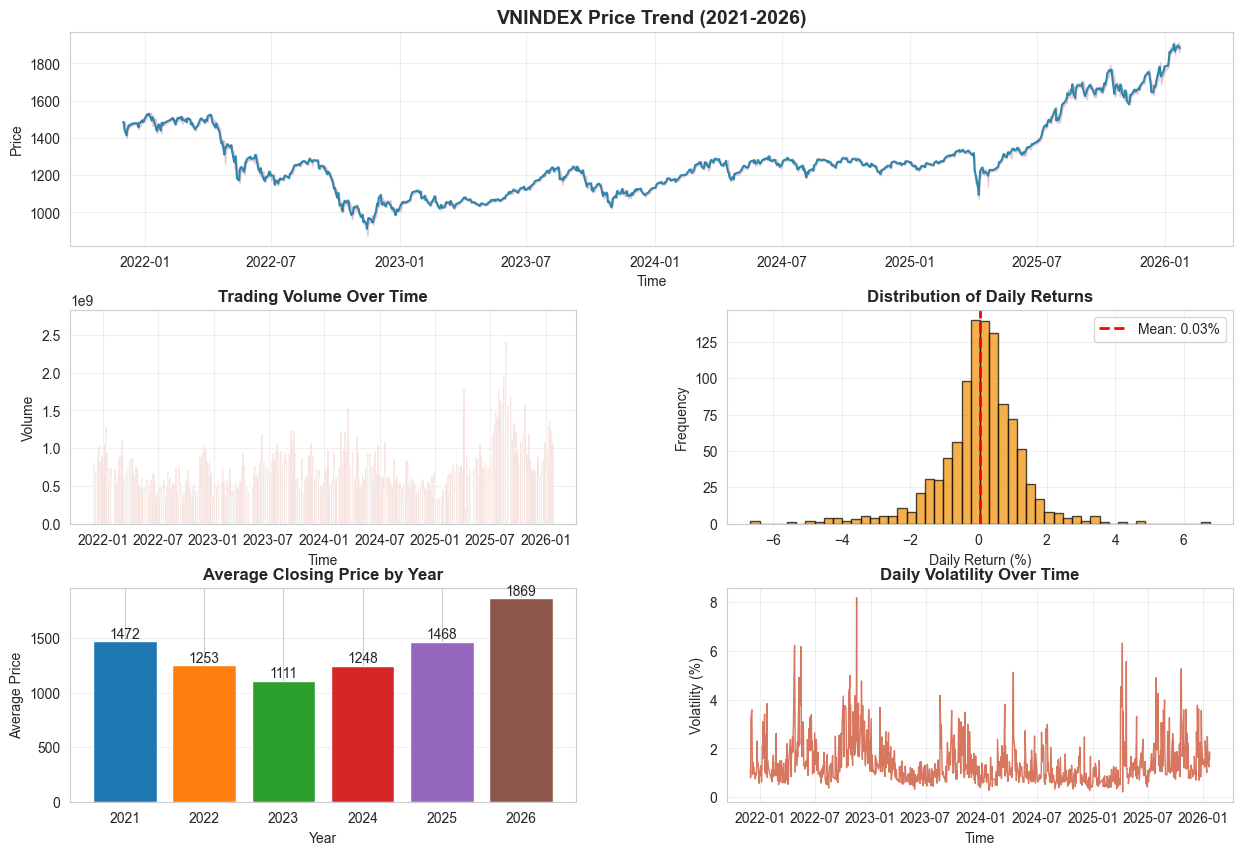


=== KEY INSIGHTS ===
Average daily return: 0.03%
Daily return std dev: 1.23%
Best day: 6.77% on 2025-04-10 00:00:00
Worst day: -6.68% on 2025-04-03 00:00:00

Price change: 1485.19 → 1882.73 (26.77%)
Average daily volatility: 1.41%
Average volume: 725,558,281


In [92]:
# Basic statistics
print("=== PRICE DATA STATISTICS ===")
print(f"Time period: {merge_df['time'].min()} to {merge_df['time'].max()}")
print(f"Total trading days: {len(merge_df)}")
print("\nPrice statistics:")
print(merge_df[['open', 'high', 'low', 'close', 'volume']].describe())

# Calculate additional metrics
merge_df['daily_return'] = merge_df['close'].pct_change() * 100
merge_df['price_range'] = merge_df['high'] - merge_df['low']
merge_df['volatility'] = (merge_df['high'] - merge_df['low']) / merge_df['open'] * 100

# Visualization
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Price trend over time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(merge_df['time'], merge_df['close'], color='#2E86AB', linewidth=1.5)
ax1.fill_between(merge_df['time'], merge_df['low'], merge_df['high'], alpha=0.2, color='#A23B72')
ax1.set_title('VNINDEX Price Trend (2021-2026)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time')
ax1.set_ylabel('Price')
ax1.grid(alpha=0.3)

# 2. Volume over time
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(merge_df['time'], merge_df['volume'], color='#C73E1D', alpha=0.6, width=1.5)
ax2.set_title('Trading Volume Over Time', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time')
ax2.set_ylabel('Volume')
ax2.grid(alpha=0.3)

# 3. Daily returns distribution
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(merge_df['daily_return'].dropna(), bins=50, color='#F18F01', edgecolor='black', alpha=0.7)
ax3.axvline(merge_df['daily_return'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {merge_df["daily_return"].mean():.2f}%')
ax3.set_title('Distribution of Daily Returns', fontsize=12, fontweight='bold')
ax3.set_xlabel('Daily Return (%)')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Price by year
ax4 = fig.add_subplot(gs[2, 0])
yearly_price = merge_df.groupby('year')['close'].mean()
bars = ax4.bar(yearly_price.index, yearly_price.values, color=[colors_by_year[year] for year in yearly_price.index])
ax4.set_title('Average Closing Price by Year', fontsize=12, fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Average Price')
ax4.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height, f'{height:.0f}', ha='center', va='bottom')

# 5. Volatility over time
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(merge_df['time'], merge_df['volatility'], color='#C73E1D', linewidth=1, alpha=0.7)
ax5.set_title('Daily Volatility Over Time', fontsize=12, fontweight='bold')
ax5.set_xlabel('Time')
ax5.set_ylabel('Volatility (%)')
ax5.grid(alpha=0.3)

# plt.suptitle('VNINDEX Market Analysis Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Additional insights
print("\n=== KEY INSIGHTS ===")
print(f"Average daily return: {merge_df['daily_return'].mean():.2f}%")
print(f"Daily return std dev: {merge_df['daily_return'].std():.2f}%")
print(f"Best day: {merge_df['daily_return'].max():.2f}% on {merge_df.loc[merge_df['daily_return'].idxmax(), 'time']}")
print(f"Worst day: {merge_df['daily_return'].min():.2f}% on {merge_df.loc[merge_df['daily_return'].idxmin(), 'time']}")
print(f"\nPrice change: {merge_df['close'].iloc[0]:.2f} → {merge_df['close'].iloc[-1]:.2f} ({((merge_df['close'].iloc[-1] / merge_df['close'].iloc[0]) - 1) * 100:.2f}%)")
print(f"Average daily volatility: {merge_df['volatility'].mean():.2f}%")
print(f"Average volume: {merge_df['volume'].mean():,.0f}")

# EDA

In [22]:
def visualize_sentiment_dashboard(df, year=2026):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_style("whitegrid")

    # ===== Copy & preprocess =====
    data = df.copy()
    data["time"] = pd.to_datetime(data["time"])
    data = data.sort_values("time")

    # ===== Feature engineering =====
    data["return"] = data["close"].pct_change()
    data["volatility"] = (data["high"] - data["low"]) / data["open"]
    data["CAR_3"] = data["return"].rolling(3).sum().shift(-2)

    sent_map = {0: "Negative", 1: "Positive", 2: "Neutral"}
    data["sent_label"] = data["date_sentiment"].map(sent_map)

    # ===== Create dashboard =====
    fig = plt.figure(figsize=(13, 8))
    gs = fig.add_gridspec(3, 2, height_ratios=[2, 1, 1])

    # =====================================================
    # 1️⃣ Price evolution with sentiment
    # =====================================================
    ax0 = fig.add_subplot(gs[0, :])
    ax0.plot(data["time"], data["close"], color="black", label="VNINDEX")

    colors = {"Positive": "green", "Negative": "red", "Neutral": "blue"}
    for s in colors:
        subset = data[data["sent_label"] == s]
        ax0.scatter(subset["time"], subset["close"],
                    color=colors[s], s=25, alpha=0.6, label=s)

    ax0.set_title(f"VNINDEX price with sentiment signals by {year}")
    ax0.legend()

    # =====================================================
    # 2️⃣ Return by sentiment
    # =====================================================
    ax1 = fig.add_subplot(gs[1, 0])
    sns.boxplot(x="sent_label", y="return", data=data, ax=ax1)
    ax1.set_title("Daily return by sentiment")

    # =====================================================
    # 3️⃣ Volatility by sentiment
    # =====================================================
    ax2 = fig.add_subplot(gs[1, 1])
    sns.boxplot(x="sent_label", y="volatility", data=data, ax=ax2)
    ax2.set_title("Volatility by sentiment")

    # =====================================================
    # 4️⃣ Volume by sentiment
    # =====================================================
    ax3 = fig.add_subplot(gs[2, 0])
    sns.boxplot(x="sent_label", y="volume", data=data, ax=ax3)
    ax3.set_title("Trading volume by sentiment")

    # =====================================================
    # 5️⃣ Event study: CAR(3)
    # =====================================================
    ax4 = fig.add_subplot(gs[2, 1])
    sns.boxplot(x="sent_label", y="CAR_3", data=data, ax=ax4)
    ax4.set_title("CAR (t+3) by sentiment")

    plt.tight_layout()
    plt.show()

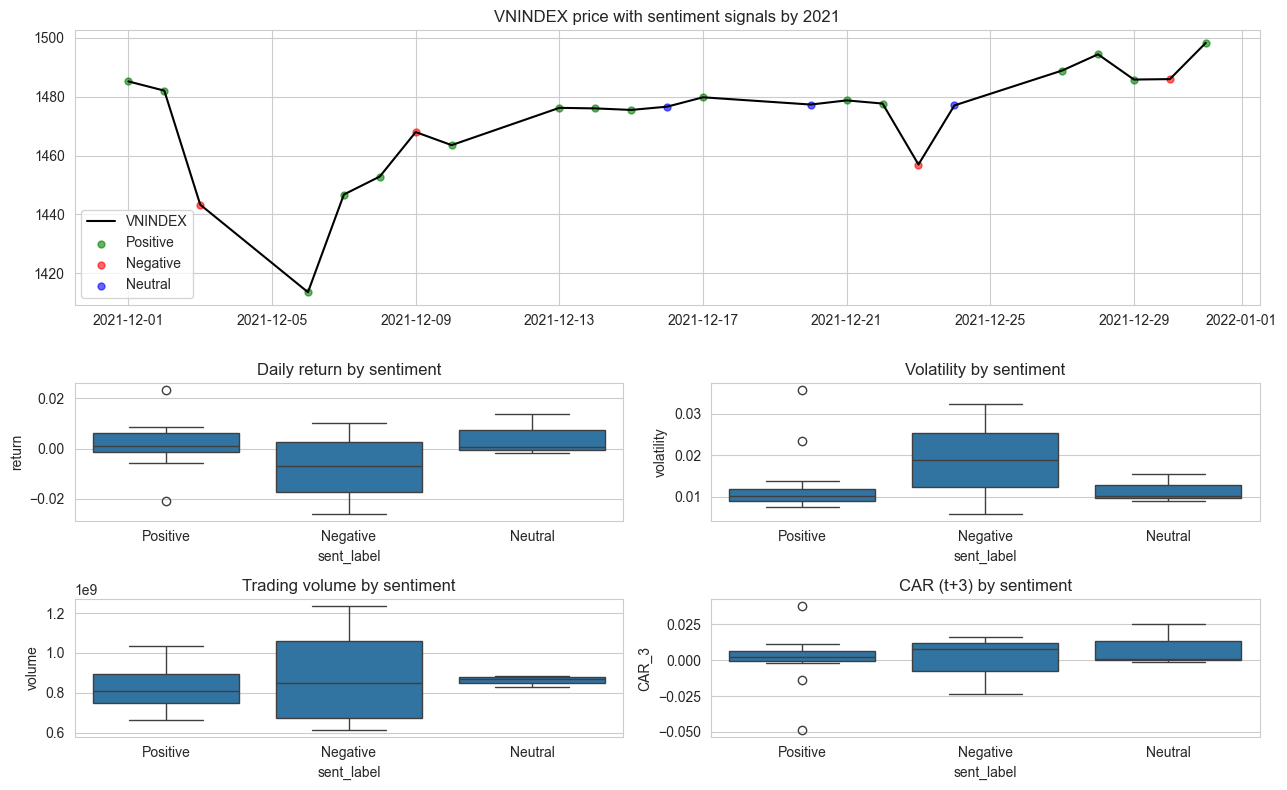

In [23]:
visualize_sentiment_dashboard(df_2021, year=2021)

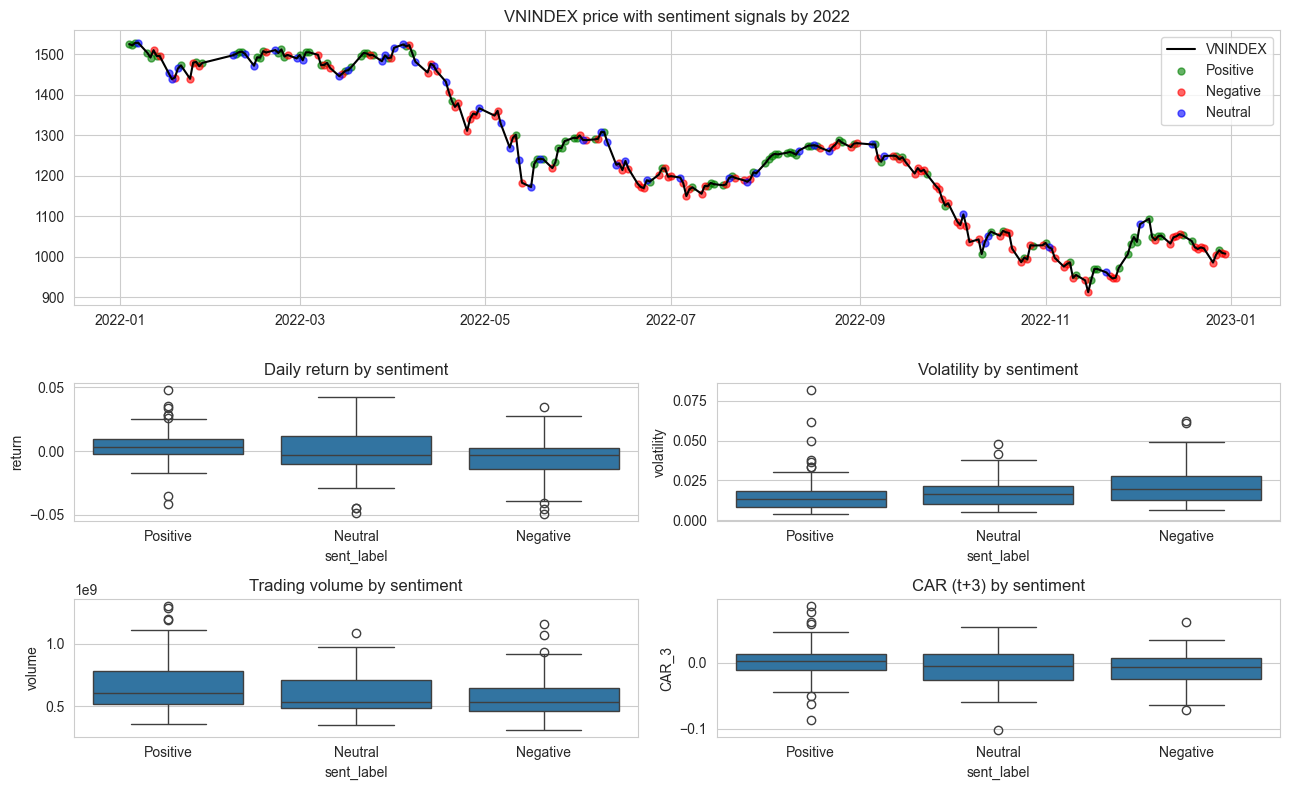

In [24]:
visualize_sentiment_dashboard(df_2022, year=2022)

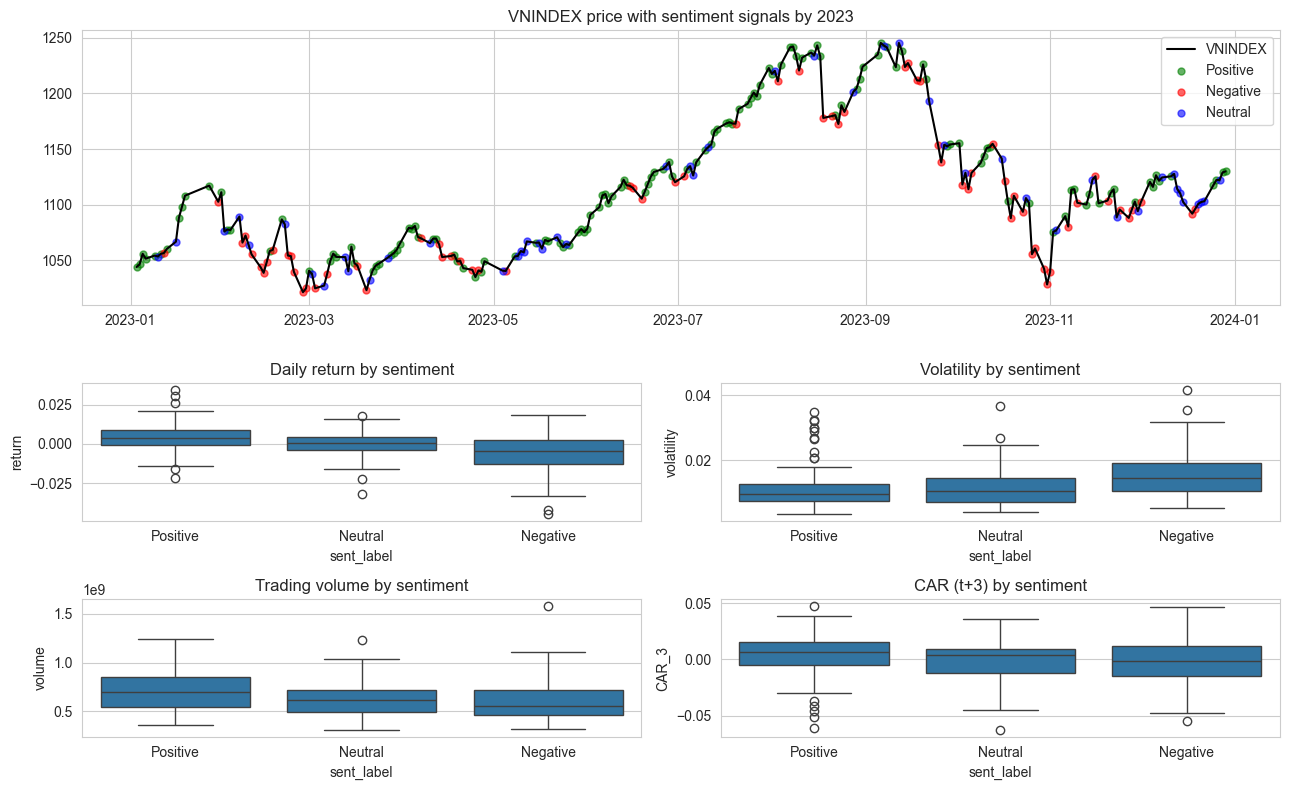

In [26]:
visualize_sentiment_dashboard(df_2023, year=2023)

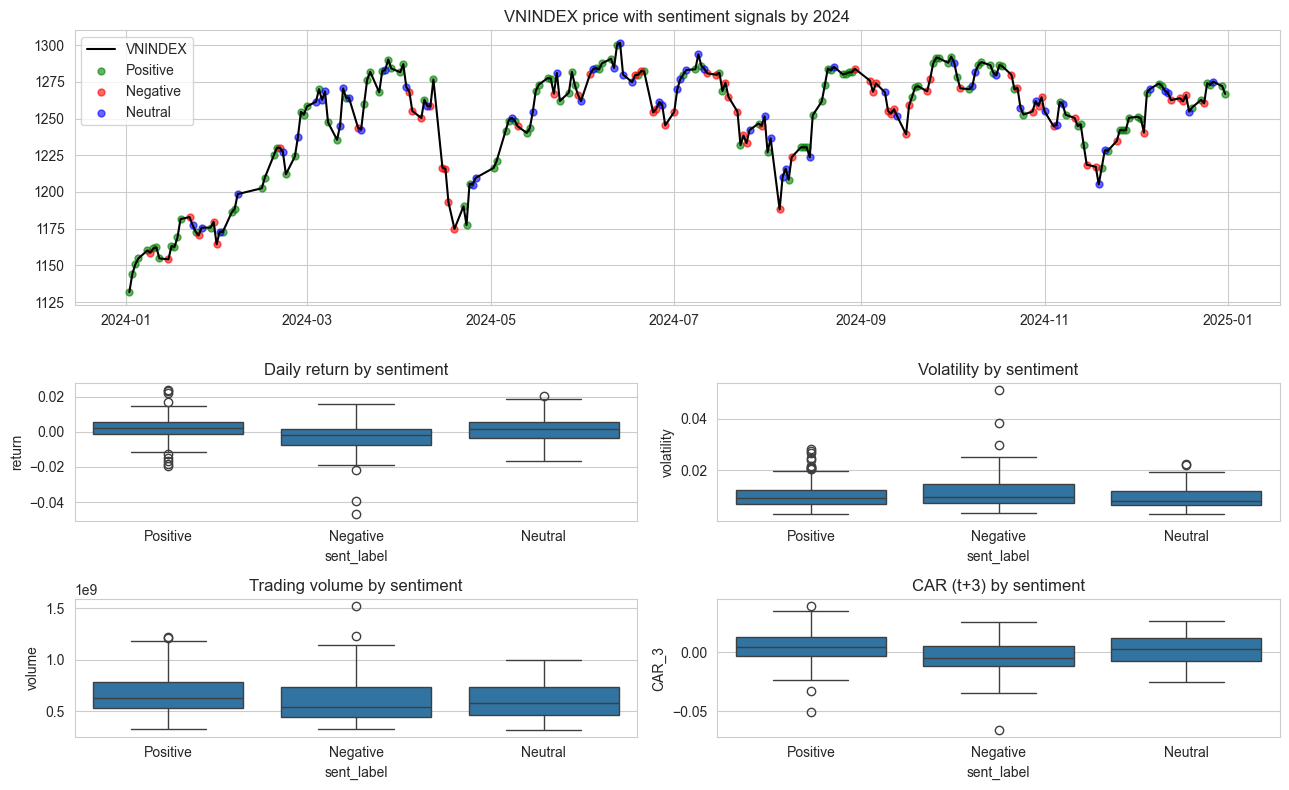

In [27]:
visualize_sentiment_dashboard(df_2024, year=2024)


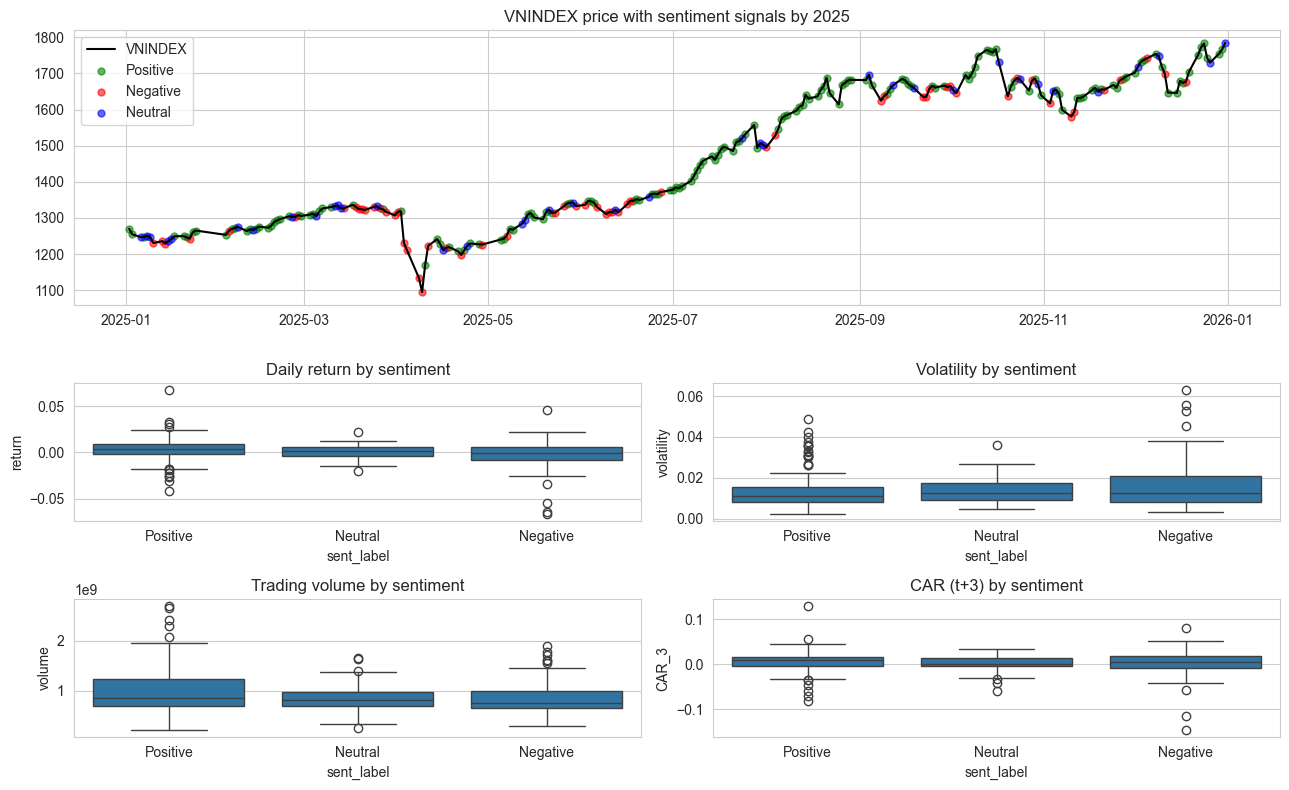

In [28]:
visualize_sentiment_dashboard(df_2025, year=2025)

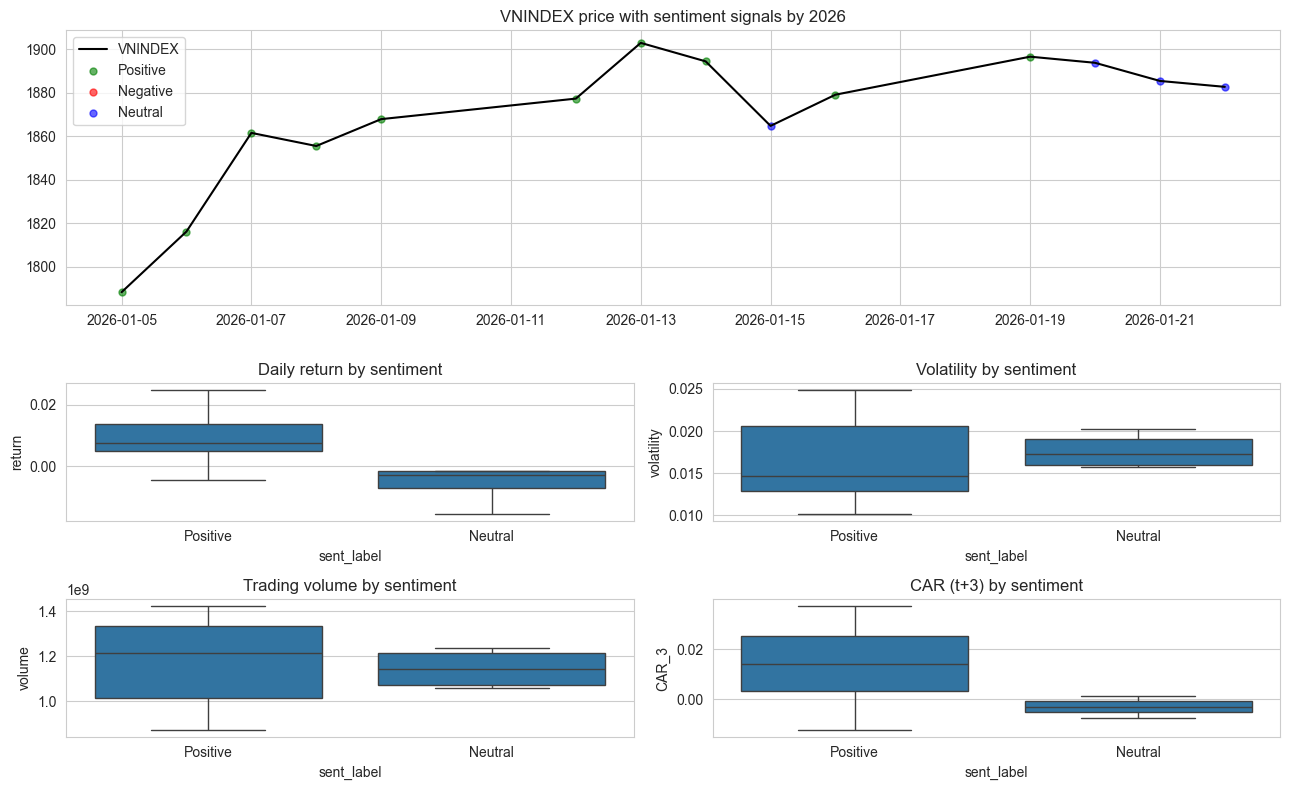

In [29]:
visualize_sentiment_dashboard(df_2026, year=2026)